# 04 - Treniranje LSTM modela

Ova sveska prati skriptu `scripts/05_train_lstm.py`. LSTM je rekurentni model koji cita poruku kao niz reci. U projektu se koristi kao dodatni model pored klasicnog TF-IDF pristupa.

Kao i kod TF-IDF modela, test skup se ne koristi tokom treniranja i izbora hiperparametara.

In [11]:
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

ROOT

PosixPath('/Users/markoraskovic/Desktop/ML projekat')

## Ucitavanje biblioteka, podataka i kandidata hiperparametara
(Limitiran vremenom nisam bio u mogucnosti da napravim testiranje po sirem skupu parametara kao za prethodni model)

In [12]:
from collections import Counter
import re

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, TensorDataset

TRAIN_PATH = ROOT / "data" / "processed" / "splits" / "train.csv"
VALIDATION_PATH = ROOT / "data" / "processed" / "splits" / "validation.csv"
MODEL_PATH = ROOT / "models" / "lstm_model.pt"
VOCAB_PATH = ROOT / "models" / "lstm_vocab.joblib"
RESULTS_PATH = ROOT / "reports" / "05_lstm_results.txt"

MAX_LEN = 50
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DROPOUT = 0.2

candidate_parameters = [
    {"max_words": 1000, "epochs": 8, "embedding_dim": 32, "lstm_dim": 32},
    {"max_words": 3000, "epochs": 8, "embedding_dim": 64, "lstm_dim": 64},
    {"max_words": 5000, "epochs": 8, "embedding_dim": 64, "lstm_dim": 64},
    {"max_words": 5000, "epochs": 12, "embedding_dim": 64, "lstm_dim": 64},
    {"max_words": 5000, "epochs": 16, "embedding_dim": 64, "lstm_dim": 64},
    {"max_words": 5000, "epochs": 20, "embedding_dim": 64, "lstm_dim": 64},
    {"max_words": 5000, "epochs": 12, "embedding_dim": 128, "lstm_dim": 128},
    {"max_words": 5000, "epochs": 16, "embedding_dim": 128, "lstm_dim": 128},
    {"max_words": 5000, "epochs": 20, "embedding_dim": 128, "lstm_dim": 128},
]

torch.manual_seed(42)
device = "mps" if torch.backends.mps.is_available() else "cpu"

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)

print(f"Uredjaj za treniranje: {device}")
print(f"Broj kandidata: {len(candidate_parameters)}")
train_df.head()

Uredjaj za treniranje: mps
Broj kandidata: 9


,label,message,label_id,char_count,word_count,digit_count,has_currency,has_long_number,normalized_message
0,ham,Subject: english language teaching at waseda u...,0,958,172,25,False,False,subject: english language teaching at waseda u...
1,ham,Subject: call for papers\n\ncall for papers 1s...,0,3013,618,61,False,True,subject: call for papers call for papers 1st a...
2,spam,Subject: free trial membership\n\nthe latest i...,1,526,155,15,False,False,subject: free trial membership the latest in a...
3,spam,Subject: hello\n\nuniversity degree programs i...,1,473,86,13,True,False,subject: hello university degree programs incr...
4,ham,Subject: sum : quantification\n\nabout four we...,0,7264,1440,62,False,True,subject: sum : quantification about four weeks...


## Tokenizacija i recnik

LSTM ne moze direktno da primi tekst. Zato poruku prvo pretvaramo u reci, a zatim svaku rec u broj iz recnika.

In [13]:
def tokenize(text):
    return re.findall(r"[a-z]+(?:'[a-z]+)?", str(text).lower())

word_counter = Counter()
for message in train_df["message"]:
    word_counter.update(tokenize(message))


def make_vocab(max_words):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in word_counter.most_common(max_words - 2):
        vocab[word] = len(vocab)
    return vocab


def encode_message(message, vocab):
    tokens = tokenize(message)
    numbers = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    numbers = numbers[:MAX_LEN]
    length = max(1, len(numbers))
    numbers += [vocab["<PAD>"]] * (MAX_LEN - len(numbers))
    return numbers, length

sample_vocab = make_vocab(1000)
print(tokenize(train_df.loc[0, "message"]))
print(encode_message(train_df.loc[0, "message"], sample_vocab)[0][:15])

['subject', 'english', 'language', 'teaching', 'at', 'waseda', 'university', 'there', 'is', 'anticipated', 'to', 'be', 'a', 'vacancy', 'for', 'a', 'permanent', 'faculty', 'member', 'in', 'the', 'area', 'of', 'english', 'language', 'teaching', 'in', 'the', 'division', 'of', 'multidisciplinary', 'studies', 'school', 'of', 'science', 'and', 'engineering', 'waseda', 'university', 'tokyo', 'starting', 'april', 'qualifications', 'ph', 'd', 'in', 'an', 'appropriate', 'field', 'of', 'humanities', 'or', 'social', 'sciences', 'including', 'linguistics', 'with', 'some', 'teaching', 'experience', 'at', 'the', 'college', 'or', 'university', 'level', 'command', 'of', 'japanese', 'parallel', 'to', 'that', 'of', 'an', 'educated', 'native', 'speaker', 'age', 'younger', 'than', 'availability', 'for', 'in', 'person', 'interview', 'in', 'tokyo', 'at', 'one', 's', 'own', 'expense', 'applications', 'must', 'be', 'submitted', 'by', 'september', 'th', 'by', 'registered', 'mail', 'with', 'resume', 'curriculum'

## Dataset i LSTM arhitektura

`TensorDataset` pakuje poruke, njihove stvarne duzine i labele. Model ima embedding sloj, LSTM sloj, dropout i linearni izlazni sloj.

In [14]:
def make_dataset(df, vocab):
    encoded_messages = [encode_message(message, vocab) for message in df["message"]]
    x = [message for message, _ in encoded_messages]
    lengths = [length for _, length in encoded_messages]
    y = [1 if label == "spam" else 0 for label in df["label"]]

    x = torch.tensor(x, dtype=torch.long)
    lengths = torch.tensor(lengths, dtype=torch.long)
    y = torch.tensor(y, dtype=torch.float32)

    return TensorDataset(x, lengths, y)


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, lstm_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, lstm_dim, batch_first=True)
        self.dropout = nn.Dropout(DROPOUT)
        self.linear = nn.Linear(lstm_dim, 1)

    def forward(self, x, lengths):
        x = self.embedding(x)
        x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(x)
        x = self.dropout(hidden[-1])
        x = self.linear(x)
        return x.squeeze(1)

## Funkcija za treniranje jednog kandidata

Spam je manjinska klasa, zato se u funkciji greske koristi `pos_weight` da spam primeri imaju veci znacaj.

In [15]:
def train_model(params):
    torch.manual_seed(42)

    vocab = make_vocab(params["max_words"])
    train_dataset = make_dataset(train_df, vocab)
    validation_dataset = make_dataset(validation_df, vocab)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

    model = LSTMClassifier(len(vocab), params["embedding_dim"], params["lstm_dim"]).to(device)

    spam_count = (train_df["label"] == "spam").sum()
    ham_count = (train_df["label"] == "ham").sum()
    pos_weight = torch.tensor([ham_count / spam_count], dtype=torch.float32).to(device)

    loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    for epoch in range(params["epochs"]):
        model.train()
        total_loss = 0

        for x_batch, lengths, y_batch in train_loader:
            x_batch = x_batch.to(device)
            lengths = lengths.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            predictions = model(x_batch, lengths)
            loss = loss_function(predictions, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(train_loader)
        print(f"  epoch {epoch + 1}/{params['epochs']} - loss: {average_loss:.8f}")

    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for x_batch, lengths, y_batch in validation_loader:
            x_batch = x_batch.to(device)
            lengths = lengths.to(device)

            logits = model(x_batch, lengths)
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).int().cpu().tolist()

            all_predictions.extend(predictions)
            all_labels.extend(y_batch.int().tolist())

    label_names = ["ham", "spam"]
    real_labels = [label_names[label] for label in all_labels]
    predicted_labels = [label_names[label] for label in all_predictions]

    spam_precision = precision_score(real_labels, predicted_labels, pos_label="spam", zero_division=0)
    spam_recall = recall_score(real_labels, predicted_labels, pos_label="spam", zero_division=0)
    spam_f1 = f1_score(real_labels, predicted_labels, pos_label="spam", zero_division=0)

    return model, vocab, real_labels, predicted_labels, spam_precision, spam_recall, spam_f1

## Treniranje kandidata i izbor najboljeg LSTM modela

Najbolji model biramo prema F1 meri za spam klasu na validacionom skupu.

In [16]:
all_results = []
best_model = None
best_vocab = None
best_params = None
best_real_labels = None
best_predicted_labels = None
best_spam_f1 = -1

for index, params in enumerate(candidate_parameters, start=1):
    print(f"\nKandidat {index}/{len(candidate_parameters)}: {params}")
    model, vocab, real_labels, predicted_labels, spam_precision, spam_recall, spam_f1 = train_model(params)

    all_results.append([
        params["max_words"],
        params["epochs"],
        params["embedding_dim"],
        params["lstm_dim"],
        spam_precision,
        spam_recall,
        spam_f1,
    ])

    if spam_f1 > best_spam_f1:
        best_spam_f1 = spam_f1
        best_model = model
        best_vocab = vocab
        best_params = params
        best_real_labels = real_labels
        best_predicted_labels = predicted_labels

results_table = pd.DataFrame(
    all_results,
    columns=["max_words", "epochs", "embedding_dim", "lstm_dim", "spam_precision", "spam_recall", "spam_f1"],
).sort_values("spam_f1", ascending=False)

results_table


Kandidat 1/9: {'max_words': 1000, 'epochs': 8, 'embedding_dim': 32, 'lstm_dim': 32}
  epoch 1/8 - loss: 1.15622923
  epoch 2/8 - loss: 1.14199298
  epoch 3/8 - loss: 1.09544539
  epoch 4/8 - loss: 0.86399194
  epoch 5/8 - loss: 0.75704299
  epoch 6/8 - loss: 0.69206619
  epoch 7/8 - loss: 0.64750335
  epoch 8/8 - loss: 0.63045054

Kandidat 2/9: {'max_words': 3000, 'epochs': 8, 'embedding_dim': 64, 'lstm_dim': 64}
  epoch 1/8 - loss: 1.14791086
  epoch 2/8 - loss: 1.05185063
  epoch 3/8 - loss: 0.70999098
  epoch 4/8 - loss: 0.46309709
  epoch 5/8 - loss: 0.53347664
  epoch 6/8 - loss: 0.44320797
  epoch 7/8 - loss: 0.35263365
  epoch 8/8 - loss: 0.24781341

Kandidat 3/9: {'max_words': 5000, 'epochs': 8, 'embedding_dim': 64, 'lstm_dim': 64}
  epoch 1/8 - loss: 1.13929858
  epoch 2/8 - loss: 1.01689456
  epoch 3/8 - loss: 0.62968541
  epoch 4/8 - loss: 0.44604092
  epoch 5/8 - loss: 0.30851709
  epoch 6/8 - loss: 0.20505157
  epoch 7/8 - loss: 0.29231931
  epoch 8/8 - loss: 0.17579247



,max_words,epochs,embedding_dim,lstm_dim,spam_precision,spam_recall,spam_f1
5,5000,20,64,64,0.970149,0.928571,0.948905
3,5000,12,64,64,0.942029,0.928571,0.935252
4,5000,16,64,64,0.969231,0.900000,0.933333
8,5000,20,128,128,0.928571,0.928571,0.928571
6,5000,12,128,128,0.888889,0.914286,0.901408
7,5000,16,128,128,0.887324,0.900000,0.893617
1,3000,8,64,64,0.846154,0.942857,0.891892
2,5000,8,64,64,0.846154,0.942857,0.891892
0,1000,8,32,32,0.760563,0.771429,0.765957


## Graficki prikaz metrika po konfiguraciji

Svaka grupa stubova predstavlja jednu LSTM konfiguraciju hiperparametara.

Visine stubova dolaze iz kolona `spam_precision`, `spam_recall` i `spam_f1` tabele `results_table`. Te vrednosti su ranije izracunate poredjenjem stvarnih oznaka `real_labels` i predikcija modela `predicted_labels` na validacionom skupu.

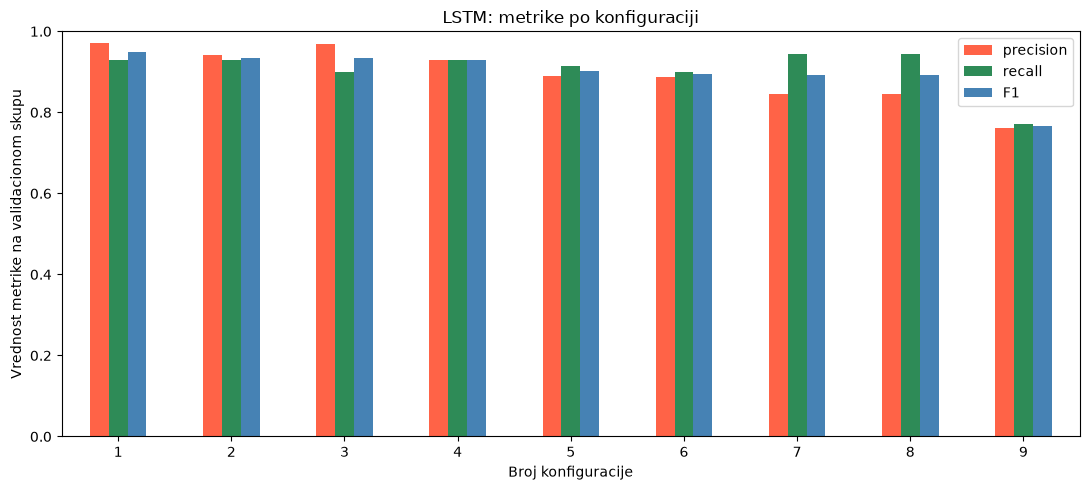

,max_words,epochs,embedding_dim,lstm_dim
broj,,,,
1,5000,20,64,64
2,5000,12,64,64
3,5000,16,64,64
4,5000,20,128,128
5,5000,12,128,128
6,5000,16,128,128
7,3000,8,64,64
8,5000,8,64,64
9,1000,8,32,32


In [17]:
metric_columns = ["spam_precision", "spam_recall", "spam_f1"]
plot_data = results_table.reset_index(drop=True)
plot_data.index = range(1, len(plot_data) + 1)

fig, ax = plt.subplots(figsize=(11, 5))
plot_data[metric_columns].plot(
    kind="bar", ax=ax, ylim=(0, 1),
    color=["tomato", "seagreen", "steelblue"],
)
ax.set_title("LSTM: metrike po konfiguraciji")
ax.set_xlabel("Broj konfiguracije")
ax.set_ylabel("Vrednost metrike na validacionom skupu")
ax.legend(["precision", "recall", "F1"])
ax.set_xticklabels(range(1, len(plot_data) + 1), rotation=0)
fig.tight_layout()
plt.show()

display(plot_data[["max_words", "epochs", "embedding_dim", "lstm_dim"]].rename_axis("broj"))

## Validacioni rezultati najboljeg modela i cuvanje

In [18]:
validation_report = classification_report(best_real_labels, best_predicted_labels)
validation_confusion_matrix = confusion_matrix(best_real_labels, best_predicted_labels, labels=["ham", "spam"])

print(f"Najbolji parametri: {best_params}")
print(validation_report)
display(pd.DataFrame(validation_confusion_matrix, index=["stvarno_ham", "stvarno_spam"], columns=["pred_ham", "pred_spam"]))

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save(best_model.state_dict(), MODEL_PATH)
joblib.dump(
    {
        "vocab": best_vocab,
        "max_len": MAX_LEN,
        "embedding_dim": best_params["embedding_dim"],
        "lstm_dim": best_params["lstm_dim"],
    },
    VOCAB_PATH,
)

with open(RESULTS_PATH, "w", encoding="utf-8") as file:
    file.write("IZBOR HIPERPARAMETARA\n")
    file.write(results_table.to_string(index=False))
    file.write(f"\n\nNajbolji parametri: {best_params}\n\n")
    file.write("VALIDACIONI SKUP\n")
    file.write(validation_report)
    file.write("\n\nMATRICA KONFUZIJE NA VALIDACIONOM SKUPU\n")
    file.write(str(pd.DataFrame(validation_confusion_matrix, index=["stvarno_ham", "stvarno_spam"], columns=["pred_ham", "pred_spam"])))

print(f"Model je sacuvan u: {MODEL_PATH}")
print(f"Recnik je sacuvan u: {VOCAB_PATH}")
print(f"Rezultati su sacuvani u: {RESULTS_PATH}")

Najbolji parametri: {'max_words': 5000, 'epochs': 20, 'embedding_dim': 64, 'lstm_dim': 64}
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       361
        spam       0.97      0.93      0.95        70

    accuracy                           0.98       431
   macro avg       0.98      0.96      0.97       431
weighted avg       0.98      0.98      0.98       431



,pred_ham,pred_spam
stvarno_ham,359,2
stvarno_spam,5,65


Model je sacuvan u: /Users/markoraskovic/Desktop/ML projekat/models/lstm_model.pt
Recnik je sacuvan u: /Users/markoraskovic/Desktop/ML projekat/models/lstm_vocab.joblib
Rezultati su sacuvani u: /Users/markoraskovic/Desktop/ML projekat/reports/05_lstm_results.txt
